In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Shared styling: muted neutral grid/text + a single blue hue for sequential
# ("more = darker") encodings, so nothing here reads as good/bad red-green.
plt.rcParams.update({
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "axes.grid": False,
    "figure.facecolor": "white",
    "font.size": 11,
})
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print('setup complete')

setup complete


# EDA Statistical Summaries

Column-level `describe()` tables for each raw source file, plus a quick look at
known sentinel values (missed calls, empty Bluetooth scans) and the gender split
of participants.

In [6]:
calls_data = pd.read_csv('../data/raw/calls.csv')
bt_data = pd.read_csv('../data/raw/bt_symmetric.csv')
fb_data = pd.read_csv('../data/raw/fb_friends.csv')
sms_data = pd.read_csv('../data/raw/sms.csv')
genders_data = pd.read_csv('../data/raw/genders.csv')

# Raw files begin with a "# "-prefixed header for the first column; strip it (same fix as cleaning.ipynb)
bt_data = bt_data.rename(columns={bt_data.columns[0]: 'timestamp'})
fb_data = fb_data.rename(columns={fb_data.columns[0]: 'user_a'})
genders_data = genders_data.rename(columns={genders_data.columns[0]: 'user'})

In [7]:
def styled_describe(df, title):
    """Transposed describe() (rows=columns) with a single-hue gradient on the mean,
    so magnitude reads as light->dark blue instead of an arbitrary red/green cue."""
    summary = df.describe().T
    return (
        summary.style
        .set_caption(title)
        .format(precision=2, thousands=",")
        .background_gradient(cmap=sns.light_palette("#2a78d6", as_cmap=True), subset=["mean"])
        .set_table_styles([
            {"selector": "caption", "props": [
                ("font-size", "14px"), ("font-weight", "bold"),
                ("text-align", "left"), ("padding-bottom", "6px"),
            ]},
            {"selector": "th", "props": [
                ("background-color", "#f0efec"), ("color", "#0b0b0b"),
            ]},
        ])
    )

for df, title in [
    (calls_data, "calls.csv"),
    (bt_data, "bt_symmetric.csv"),
    (fb_data, "fb_friends.csv"),
    (sms_data, "sms.csv"),
    (genders_data, "genders.csv"),
]:
    display(styled_describe(df, title))

,count,mean,std,min,25%,50%,75%,max
timestamp,"3,600.00","1,281,669.82","666,288.92",184.00,"750,183.25","1,250,541.50","1,819,620.25","2,416,399.00"
caller,"3,600.00",349.84,226.33,0.00,143.00,335.00,560.00,846.00
callee,"3,600.00",354.58,221.14,0.00,163.75,354.00,552.00,845.00
duration,"3,600.00",56.79,176.86,-1.00,0.00,10.00,50.00,"5,138.00"


,count,mean,std,min,25%,50%,75%,max
timestamp,"5,474,289.00","1,217,628.75","678,657.01",0.00,"676,200.00","1,206,000.00","1,801,500.00","2,418,900.00"
user_a,"5,474,289.00",379.10,194.78,0.00,221.00,394.00,543.00,845.00
user_b,"5,474,289.00",95.69,149.56,-2.00,-1.00,-1.00,166.00,704.00
rssi,"5,474,289.00",-49.95,42.07,-107.00,-88.00,-74.00,0.00,20.00


,count,mean,std,min,25%,50%,75%,max
user_a,"6,429.00",258.46,183.90,0.00,104.00,221.00,386.00,824.00
user_b,"6,429.00",542.40,204.57,13.00,393.00,564.00,711.00,850.00


,count,mean,std,min,25%,50%,75%,max
timestamp,"24,333.00","1,161,996.27","688,301.43",18.00,"574,405.00","1,080,494.00","1,729,376.00","2,418,982.00"
sender,"24,333.00",335.71,212.40,0.00,152.00,296.00,531.00,846.00
recipient,"24,333.00",334.69,213.05,0.00,149.00,296.00,540.00,846.00


,count,mean,std,min,25%,50%,75%,max
user,787.00,414.94,240.36,0.00,208.50,414.00,621.50,847.00
female,787.00,0.22,0.41,0.00,0.00,0.00,0.00,1.00


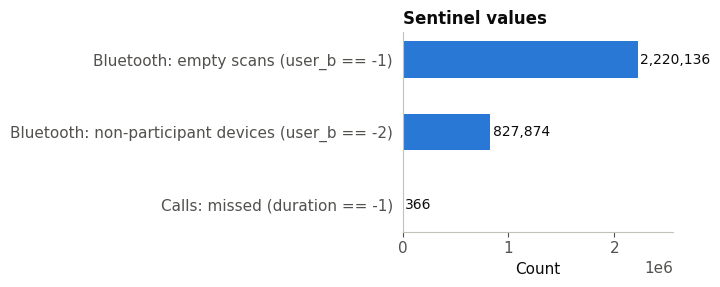

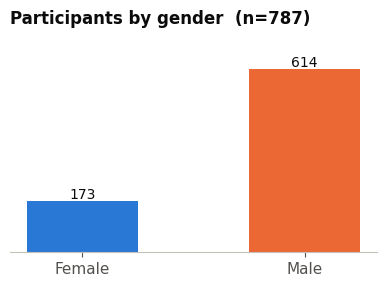

In [8]:
# Sentinel values worth accounting for before any modeling
sentinel_counts = pd.Series({
    "Bluetooth: empty scans (user_b == -1)": (bt_data['user_b'] == -1).sum(),
    "Bluetooth: non-participant devices (user_b == -2)": (bt_data['user_b'] == -2).sum(),
    "Calls: missed (duration == -1)": (calls_data['duration'] == -1).sum(),
}).sort_values()

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(sentinel_counts.index, sentinel_counts.values, color="#2a78d6", height=0.5)
for bar, value in zip(bars, sentinel_counts.values):
    ax.text(
        bar.get_width() + sentinel_counts.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,}", va="center", fontsize=10,
    )
ax.set_xlim(0, sentinel_counts.max() * 1.15)
ax.set_xlabel("Count")
ax.set_title("Sentinel values", loc="left", fontsize=12, fontweight="bold")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False)
plt.tight_layout()
plt.show()

# Participants by gender
gender_counts = genders_data['female'].value_counts().rename({0: "Male", 1: "Female"}).sort_index()
fig, ax = plt.subplots(figsize=(4, 3))
bars = ax.bar(gender_counts.index, gender_counts.values, color=["#2a78d6", "#eb6834"], width=0.5)
for bar, value in zip(bars, gender_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + gender_counts.max() * 0.01,
        f"{value:,}", ha="center", fontsize=10,
    )
ax.set_ylim(0, gender_counts.max() * 1.2)
ax.set_yticks([])
ax.set_title(
    f"Participants by gender  (n={genders_data['user'].nunique():,})",
    loc="left", fontsize=12, fontweight="bold",
)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False)
plt.tight_layout()
plt.show()